# Similaridade de cidades brasileiras

- **Fonte (IDH)**: https://www.undp.org/pt/brazil/idhm-municipios-2010
- **Demais**: IBGE, KOPPEN

In [1]:
!pip install Igraph

## Setup

In [16]:
# Importação das bibliotecas
from igraph import Graph
from igraph import plot
import pandas as pd
import numpy as np
# Para o heatmap usa o seaborn
import matplotlib.pyplot as plt
import seaborn as sns

In [176]:
df = pd.read_excel('municipios_brasil.xlsx', index_col="municipio_id", decimal=",")
df.drop(columns=['altitude'], inplace=True)
df

,municipio_nome,pib_per_capita,populacao,idhm,temperatura_anual,chuva_anual
municipio_id,,,,,,
1600105,Amapa,27.6,733.8,642.0,27.3,266.0
2800308,Aracaju,37.0,602.8,770.0,26.0,125.3
1702208,Araguatins,14.5,31.9,631.0,27.4,141.2
3506003,Bauru,54.5,379.0,801.0,20.9,115.8
1501402,Belém,31.1,1303.4,746.0,27.9,250.7
3106200,Belo Horizonte,56.2,2315.6,810.0,19.1,128.9
1400100,Boa Vista,44.1,413.5,752.0,25.4,150.7
5300108,Brasília,129.8,2817.3,824.0,21.0,127.6
5002704,Campo Grande,47.1,898.1,784.0,22.3,134.0


## Correlação entre municípios

In [177]:
mat_corr = df.drop(columns=['municipio_nome']).T.corr()
mat_corr

municipio_id,1600105,2800308,1702208,3506003,1501402,3106200,1400100,5300108,5002704,5103007,...,2611606,1200401,3304557,2927408,3548500,2111300,3550308,3552205,2211001,3205309
municipio_id,,,,,,,,,,,,,,,,,,,,,
1600105,1.000000,0.947562,0.511912,0.824672,0.957166,0.861204,0.871046,0.825986,0.979732,0.447553,...,0.930113,0.850014,0.733427,0.847210,0.842454,0.978950,0.703401,0.962373,0.979087,0.757381
2800308,0.947562,1.000000,0.708000,0.953609,0.857110,0.732398,0.972221,0.686118,0.964968,0.667658,...,0.834964,0.953666,0.559137,0.707220,0.947216,0.929664,0.520286,0.988243,0.963783,0.915181
1702208,0.511912,0.708000,1.000000,0.882807,0.259042,0.039970,0.852885,-0.026492,0.499095,0.989721,...,0.205886,0.883540,-0.186740,0.005299,0.888258,0.403409,-0.231527,0.597120,0.495207,0.920049
3506003,0.824672,0.953609,0.882807,1.000000,0.663669,0.495092,0.995706,0.438002,0.841984,0.860204,...,0.631421,0.993581,0.285447,0.462624,0.992329,0.776048,0.240858,0.902561,0.839230,0.993655
1501402,0.957166,0.857110,0.259042,0.663669,1.000000,0.971393,0.719787,0.953601,0.959867,0.196924,...,0.995194,0.680344,0.897713,0.964677,0.668770,0.985765,0.877325,0.913592,0.960844,0.578559
3106200,0.861204,0.732398,0.039970,0.495092,0.971393,1.000000,0.554523,0.997598,0.885267,-0.014308,...,0.985992,0.501937,0.973992,0.999148,0.488126,0.930276,0.962496,0.819759,0.887390,0.401764
1400100,0.871046,0.972221,0.852885,0.995706,0.719787,0.554523,1.000000,0.498663,0.877769,0.820819,...,0.685110,0.996831,0.351702,0.524477,0.994568,0.820363,0.308266,0.927403,0.875291,0.979722
5300108,0.825986,0.686118,-0.026492,0.438002,0.953601,0.997598,0.498663,1.000000,0.852822,-0.077557,...,0.972501,0.443513,0.986342,0.998686,0.430075,0.903648,0.977744,0.781875,0.854967,0.343013
5002704,0.979732,0.964968,0.499095,0.841984,0.959867,0.885267,0.877769,0.852822,1.000000,0.451065,...,0.949992,0.845058,0.756876,0.867744,0.835728,0.993316,0.725928,0.990712,0.999875,0.779849


## Heatmap das correlações

In [178]:
# Pega apenas 10 cidades pra mostrar no Heatmap usando o sample
# Com reproducibilidade
df_redux = df.sample(10, random_state=42)
df_redux

,municipio_nome,pib_per_capita,populacao,idhm,temperatura_anual,chuva_anual
municipio_id,,,,,,
2111300,São Luís,40.8,1037.8,768.0,27.8,169.0
2211001,Teresina,34.0,866.3,751.0,27.1,122.3
1501402,Belém,31.1,1303.4,746.0,27.9,250.7
4106902,Curitiba,67.9,1773.7,823.0,17.1,129.6
3304557,Rio De Janeiro,73.0,6730.7,799.0,22.1,115.8
4314902,Porto Alegre,78.6,1332.8,805.0,18.6,128.1
1400100,Boa Vista,44.1,413.5,752.0,25.4,150.7
1100205,Porto Velho,55.2,460.4,736.0,25.9,208.1
2408102,Natal,41.5,751.3,763.0,26.0,114.2


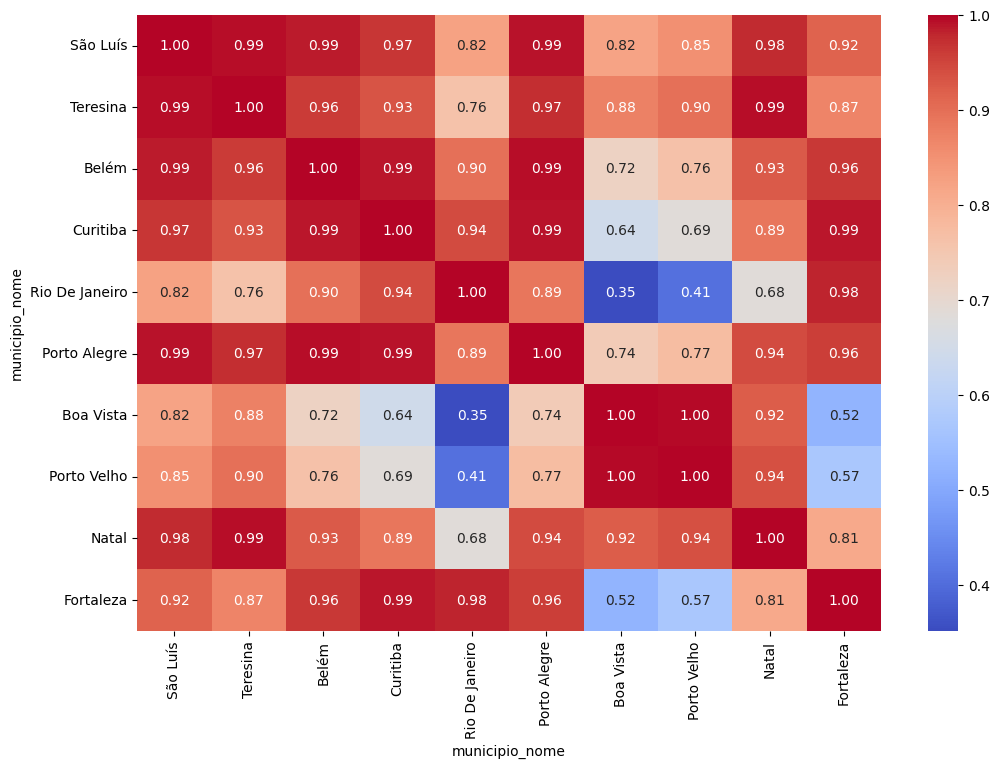

In [179]:
mat_corr_nome = df_redux.reset_index().set_index('municipio_nome').drop(columns=['municipio_id']).T.corr()
mat_corr_nome

plt.figure(figsize=(12, 8))
sns.heatmap(mat_corr_nome, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

## Peso por correlação

Pega as cidades mais semelhantes entre si

Note que utiliza o id dos municipios porque teoricamente nome poderia repetir

In [191]:
# Exclue diagonal principal (tem auto-correlação de 1.0 lá!)
np.fill_diagonal(mat_corr.values, np.nan)

def get_n_mais_simi(row, n=3):
    linha_ord = row.dropna().sort_values(ascending=False)
    results = []
    for i in range(n):
        if i < len(linha_ord):
            results.extend([linha_ord.index[i], linha_ord.iloc[i]])
        else:
            results.extend([np.nan, np.nan])
    return tuple(results)

n_similares = 3

# Aplica a função coluna a coluna
top_n_corr = mat_corr.apply(lambda row: get_n_mais_simi(row, n=n_similares), axis=1)

# Dynamically generate column names
column_names = []
for i in range(n_similares):
    column_names.extend([f'{i+1}o_municipio_id', f'{i+1}o_forca_corr'])

df_result = pd.DataFrame(top_n_corr.tolist(),
                         index=mat_corr.index,
                         columns=column_names)

df_result_ord = df_result.sort_values(by=f'1o_forca_corr', ascending=False).reset_index()
df_result_ord.head()


,municipio_id,1o_municipio_id,1o_forca_corr,2o_municipio_id,2o_forca_corr,3o_municipio_id,3o_forca_corr
0,4314902,3518800,0.999917,5208707,0.998804,2611606,0.996050
1,3518800,4314902,0.999917,5208707,0.999271,2611606,0.996980
2,5002704,2211001,0.999875,2507507,0.998979,2704302,0.994847
3,2211001,5002704,0.999875,2507507,0.998790,2704302,0.995284
4,2927408,2304400,0.999868,3106200,0.999148,1302603,0.999065


In [192]:
# Ids únicos
list_of_series_to_concat = [df_result_ord['municipio_id']]
for i in range(n_similares):
    col_name = f'{i+1}o_municipio_id'
    list_of_series_to_concat.append(df_result_ord[col_name])
todos_municipio_ids = pd.concat(list_of_series_to_concat).dropna().unique()

map_id_novoid = {original_id: new_id for new_id, original_id in enumerate(todos_municipio_ids)}

mapa_id_nome = df['municipio_nome'].to_dict()

df_result_ord['municipio_novo_id'] = df_result_ord['municipio_id'].map(map_id_novoid)
df_result_ord['municipio_nome'] = df_result_ord['municipio_id'].map(mapa_id_nome)

for i in range(n_similares):
    original_id_col = f'{i+1}o_municipio_id'
    new_id_col = f'{i+1}o_municipio_novo_id'
    df_result_ord[new_id_col] = df_result_ord[original_id_col].map(map_id_novoid)

    new_name_col = f'{i+1}o_municipio_nome'
    df_result_ord[new_name_col] = df_result_ord[original_id_col].map(mapa_id_nome)

all_edges = []
all_weights = []

for index, row in df_result_ord.iterrows():
    source_id = int(row['municipio_novo_id'])
    for i in range(n_similares):
        target_id_col = f'{i+1}o_municipio_novo_id'
        weight_col = f'{i+1}o_forca_corr'

        if pd.notna(row[target_id_col]) and pd.notna(row[weight_col]):
            target_id = int(row[target_id_col])
            weight = float(row[weight_col])
            all_edges.append((source_id, target_id))
            all_weights.append(weight)

id_edges = all_edges
pesos_mun = all_weights

display_cols = ['municipio_novo_id', 'municipio_nome']
for i in range(n_similares):
    display_cols.extend([f'{i+1}o_municipio_novo_id', f'{i+1}o_municipio_nome', f'{i+1}o_forca_corr'])
display(df_result_ord[display_cols])

,municipio_novo_id,municipio_nome,1o_municipio_novo_id,1o_municipio_nome,1o_forca_corr,2o_municipio_novo_id,2o_municipio_nome,2o_forca_corr,3o_municipio_novo_id,3o_municipio_nome,3o_forca_corr
0,0,Porto Alegre,1,Guarulhos,0.999917,10,Goiania,0.998804,11,Recife,0.996050
1,1,Guarulhos,0,Porto Alegre,0.999917,10,Goiania,0.999271,11,Recife,0.996980
2,2,Campo Grande,3,Teresina,0.999875,13,João Pessoa,0.998979,6,Maceió,0.994847
3,3,Teresina,2,Campo Grande,0.999875,13,João Pessoa,0.998790,6,Maceió,0.995284
4,4,Salvador,5,Fortaleza,0.999868,9,Belo Horizonte,0.999148,8,Manaus,0.999065
5,5,Fortaleza,4,Salvador,0.999868,9,Belo Horizonte,0.999211,12,Brasília,0.999114
6,6,Maceió,7,São Luís,0.999838,3,Teresina,0.995284,2,Campo Grande,0.994847
7,7,São Luís,6,Maceió,0.999838,3,Teresina,0.993721,2,Campo Grande,0.993316
8,8,Manaus,9,Belo Horizonte,0.999297,4,Salvador,0.999065,5,Fortaleza,0.998527
9,9,Belo Horizonte,8,Manaus,0.999297,5,Fortaleza,0.999211,4,Salvador,0.999148


In [193]:
nomes_mun = [mapa_id_nome[original_id].capitalize() for original_id in todos_municipio_ids]
nomes_mun[:5]

['Porto alegre', 'Guarulhos', 'Campo grande', 'Teresina', 'Salvador']

Note que é espelhado, sempre vai ter dois redundantes (Cidade X -> Cidade Y e Cidade Y -> Cidade X)

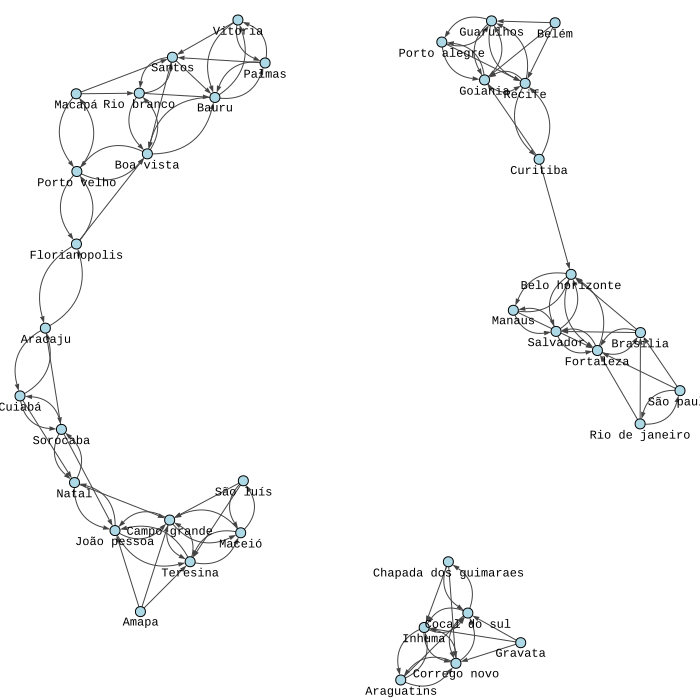

In [194]:
import igraph as ig
# O número de vértices deve ser o total de IDs únicos
# e as arestas são id_edges
grafo = ig.Graph(len(todos_municipio_ids), edges = id_edges, directed = True)

grafo.vs['label'] = nomes_mun
grafo.es['weight'] = pesos_mun

# Plotando com fundo nos rótulos usando os parâmetros nativos do igraph
p = ig.plot(
    grafo,
    bbox=(0,0,700,700),
    vertex_size=10,
    vertex_color='lightblue',
    vertex_label_dist=1.2,
    vertex_label_background='black',
    vertex_label_size=12,
    edge_arrow_size=0.5,
)
p.save(f"{n_similares}_cidades_similares.png")
p

Com três mais próximos fica uma bagunça.